# Exploratory analysis and feature screening

This notebook examines the processed ATcT molecular dataset, evaluates
descriptor correlations and sparsity, and establishes a Random Forest
baseline with a molecular-charge ablation test.


In [1]:
import numpy as np
import pandas as pd
import re

import matplotlib.pyplot as plt

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model

## 1. Load and inspect the processed dataset


In [2]:
filename = "../data/ATcT_bonds_corrected.csv"

df = pd.read_csv(filename)

print(df.shape)
df.head()

(3268, 109)


,species_name,formula,dHf_0K,dHf_298K,units,atct_id,molar_mass,molar_mass_uncertainty,cas_number,atct_seq,...,H-Pt_S,O-S_A,S-S_A,N-S_S,Structure_source,SINGLE,num_bonds,TRIPLE,DOUBLE,AROMATIC
0,Dihydrogen,H2 (g),0.0,0.0,NaN,1333-74-0*0,2.015880,0.000140,1333-74-0,0,...,0,0,0,0,PubChem,1,1,0,0,0
1,Dinitrogen,N2 (g),0.0,0.0,NaN,7727-37-9*0,28.013480,0.000140,7727-37-9,0,...,0,0,0,0,PubChem,0,1,1,0,0
2,Dioxygen,O2 (g),0.0,0.0,NaN,7782-44-7*0,31.998800,0.000600,7782-44-7,0,...,0,0,0,0,PubChem,0,1,0,1,0
3,Difluorine,F2 (g),0.0,0.0,NaN,7782-41-4*0,37.996806,0.000001,7782-41-4,0,...,0,0,0,0,PubChem,1,1,0,0,0
4,Dichlorine,Cl2 (g),0.0,0.0,NaN,7782-50-5*0,70.905400,0.001800,7782-50-5,0,...,0,0,0,0,PubChem,1,1,0,0,0


In [3]:
df.describe(include="all")

,species_name,formula,dHf_0K,dHf_298K,units,atct_id,molar_mass,molar_mass_uncertainty,cas_number,atct_seq,...,H-Pt_S,O-S_A,S-S_A,N-S_S,Structure_source,SINGLE,num_bonds,TRIPLE,DOUBLE,AROMATIC
count,3268,3268,2688.000000,3268.00000,3260,3268,3268.000000,3.268000e+03,3268,3268.000000,...,3268.000000,3268.000000,3268.000000,3268.000000,3268,3268.000000,3268.000000,3268.000000,3268.000000,3268.000000
unique,1754,3268,NaN,NaN,1,3268,NaN,NaN,1666,NaN,...,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN
top,Hydrogen fluoride,H2 (g),NaN,NaN,kJ/mol,1333-74-0*0,NaN,NaN,7664-39-3,NaN,...,NaN,NaN,NaN,NaN,PubChem,NaN,NaN,NaN,NaN,NaN
freq,48,1,NaN,NaN,3260,1,NaN,NaN,48,NaN,...,NaN,NaN,NaN,NaN,3267,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,338.294766,207.15787,NaN,NaN,65.997009,2.297216e-03,NaN,162.638617,...,0.000306,0.001224,0.000306,0.000306,NaN,4.111077,5.266218,0.173195,0.611995,0.369951
std,NaN,NaN,555.556313,605.10848,NaN,NaN,48.191476,2.980236e-03,NaN,312.364614,...,0.017493,0.049469,0.017493,0.017493,NaN,4.932935,5.956284,0.451495,0.815748,2.696444
min,NaN,NaN,-2006.950000,-5170.55000,NaN,NaN,2.015330,8.000000e-10,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,-42.710000,-156.65000,NaN,NaN,42.036700,8.600000e-04,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,2.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,219.735000,98.77500,NaN,NaN,54.069150,1.600000e-03,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,3.000000,4.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,658.600000,516.02500,NaN,NaN,77.103525,2.600000e-03,NaN,13.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,6.000000,7.000000,0.000000,1.000000,0.000000


In [4]:
df.isna().sum().sort_values(ascending=False)

uncertainty_kJmol    3260
dHf_0K                580
Canonical_SMILES       56
Isomeric_SMILES        56
CID                    56
                     ... 
C-N_T                   0
F-H_S                   0
C-C_A                   0
Cl-H_S                  0
AROMATIC                0
Length: 109, dtype: int64

In [5]:
duplicate_like = [
    col for col in df.columns 
    if re.search(r"\.\d+$", col)
]

print("Remaining duplicate-like columns:")
print(duplicate_like)

Remaining duplicate-like columns:
[]


In [6]:
original_rows = len(df)

df = (
    df.dropna(
        subset=[
            "species_name",
            "dHf_298K",
            "Canonical_SMILES",
        ]
    )
    .reset_index(drop=True)
)

print(f"Original rows: {original_rows}")
print(f"Usable molecular rows: {len(df)}")


Original rows: 3268
Usable molecular rows: 3212


## 2. Target distribution and initial feature definition


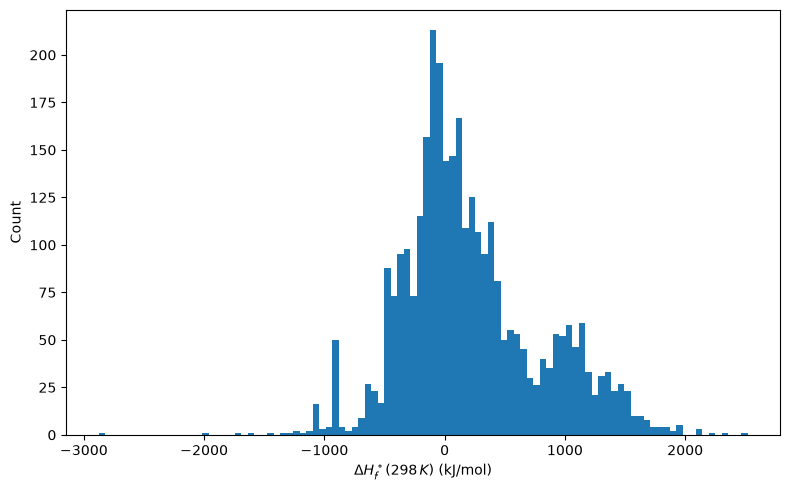

In [7]:
target = "dHf_298K"
plt.figure(figsize=(8,5))

plt.hist(df[target], bins=100)

plt.xlabel(r"$\Delta H_f^\circ(298\,K)$ (kJ/mol)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

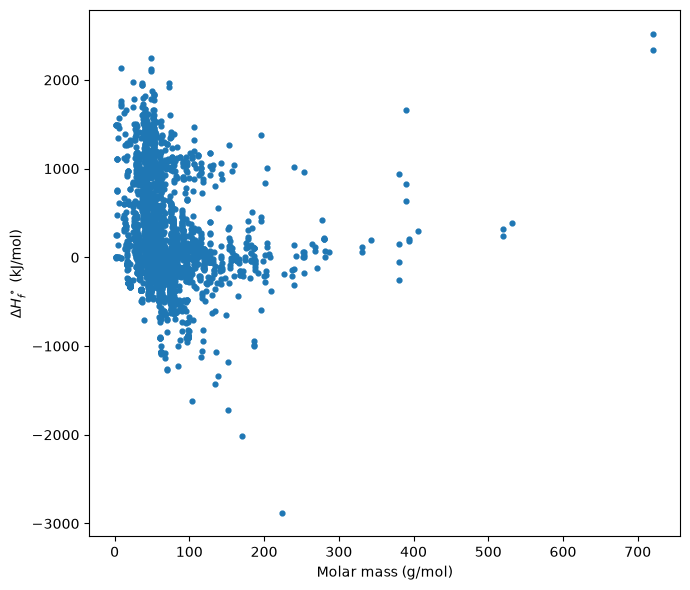

In [8]:
plt.figure(figsize=(7,6))

plt.scatter(df["molar_mass"],
            df["dHf_298K"],
            s=12)

plt.xlabel("Molar mass (g/mol)")
plt.ylabel(r"$\Delta H_f^\circ$ (kJ/mol)")

plt.tight_layout()
plt.show()

In [9]:
print(df.columns.tolist())

['species_name', 'formula', 'dHf_0K', 'dHf_298K', 'units', 'atct_id', 'molar_mass', 'molar_mass_uncertainty', 'cas_number', 'atct_seq', 'uncertainty_kJmol', 'species_type', 'number_of_atoms', 'cleaned_formula', 'number_of_elements', 'CID', 'Canonical_SMILES', 'Isomeric_SMILES', 'InChI', 'H-H_S', 'N-N_T', 'O-O_D', 'F-F_S', 'Cl-Cl_S', 'Br-Br_S', 'I-I_S', 'C-H_S', 'H-O_S', 'C-O_D', 'C-C_S', 'C-C_D', 'C-O_S', 'H-N_S', 'C-O_T', 'C-C_T', 'Cl-H_S', 'C-C_A', 'F-H_S', 'C-N_T', 'Br-H_S', 'N-O_D', 'C-N_S', 'C-Cl_S', 'O-O_S', 'H-I_S', 'N-O_S', 'C-F_S', 'H-Si_S', 'O-S_D', 'Br-C_S', 'Cl-O_S', 'C-N_D', 'Br-O_S', 'C-I_S', 'H-S_S', 'F-O_S', 'C-Si_S', 'O-S_S', 'F-Si_S', 'I-O_S', 'O-Si_S', 'Cl-F_S', 'N-N_D', 'F-N_S', 'C-N_A', 'Si-Si_S', 'N-O_T', 'Si-Si_D', 'S-S_D', 'C-S_S', 'O-Si_D', 'I-O_D', 'N-N_S', 'Cl-I_S', 'Br-Si_S', 'Cl-Si_S', 'C-S_D', 'C-O_A', 'B-O_S', 'B-Cl_S', 'Br-I_S', 'Cl-N_S', 'B-H_S', 'C-Si_T', 'B-F_S', 'Si-Si_T', 'B-C_S', 'B-N_S', 'I-Si_S', 'Cl-S_S', 'C-S_T', 'B-N_T', 'O-O_A', 'I-I_D', 'C-I

## 3. Correlation analysis


In [14]:
bond_columns = [
    column for column in df.columns
    if column.endswith(("_S", "_D", "_T", "_A"))
]

X_bond = df[bond_columns].copy()
y = df["dHf_298K"].copy()

Xy = X_bond.copy()
Xy["dHf_298K"] = y

Xy = Xy.select_dtypes(include="number")

corr = Xy.corr(method="pearson")

dHf_corr = corr["dHf_298K"].sort_values(
    ascending=False
)

print(dHf_corr)

dHf_298K    1.000000
H-Pt_S      0.035583
C-C_T       0.035216
N-O_T       0.023458
N-S_S       0.019343
              ...   
O-S_S      -0.140434
C-H_S      -0.163346
C-O_S      -0.169462
C-O_D      -0.189735
H-O_S      -0.241539
Name: dHf_298K, Length: 85, dtype: float64


In [15]:
corr = corr.dropna()

In [16]:
corr_values = (
    corr["dHf_298K"]
    .drop("dHf_298K")
    .dropna()
)

positive = corr_values.sort_values(ascending=False).head(20)
negative = corr_values.sort_values(ascending=True).head(20)

print("Positive correlations")
print(positive)

print("\nNegative correlations")
print(negative)

Positive correlations
H-Pt_S     0.035583
C-C_T      0.035216
N-O_T      0.023458
N-S_S      0.019343
N-N_A      0.016533
N-N_T      0.012231
Si-Si_T    0.011473
Si-Si_S    0.011119
N-N_D      0.010541
C-O_T      0.009528
C-N_T      0.008947
Si-Si_D    0.005068
O-O_D      0.003678
O-O_A      0.002130
C-S_T      0.002052
N-O_A      0.001704
N-N_S     -0.000344
C-Si_T    -0.000792
C-I_D     -0.001996
I-I_D     -0.001996
Name: dHf_298K, dtype: float64

Negative correlations
H-O_S    -0.241539
C-O_D    -0.189735
C-O_S    -0.169462
C-H_S    -0.163346
O-S_S    -0.140434
O-S_D    -0.138877
C-F_S    -0.128390
B-O_S    -0.124682
C-C_S    -0.115299
H-N_S    -0.098037
O-Si_D   -0.078185
F-Si_S   -0.077211
C-Cl_S   -0.070691
F-H_S    -0.069207
N-O_S    -0.058616
C-N_S    -0.054463
C-Si_S   -0.047148
N-O_D    -0.046059
O-O_S    -0.045550
B-F_S    -0.041173
Name: dHf_298K, dtype: float64


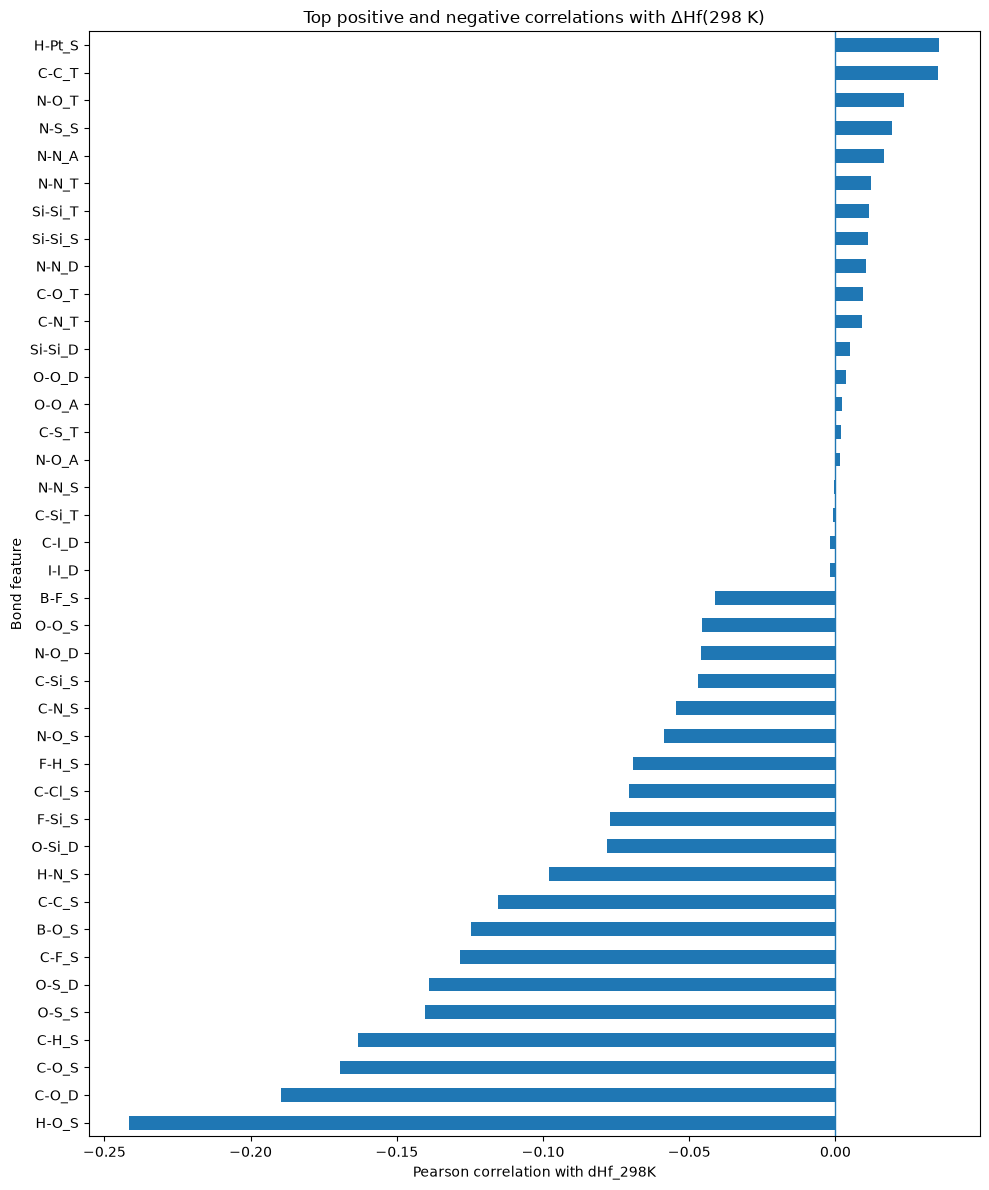

In [17]:
top_corr = pd.concat([positive, negative])

# Remove duplicated features if any
top_corr = top_corr[~top_corr.index.duplicated()]

# Sort for plotting
top_corr = top_corr.sort_values()

plt.figure(figsize=(10,12))

top_corr.plot(
    kind="barh"
)

plt.axvline(0, linewidth=1)

plt.xlabel("Pearson correlation with dHf_298K")
plt.ylabel("Bond feature")

plt.title("Top positive and negative correlations with ΔHf(298 K)")

plt.tight_layout()
plt.show()

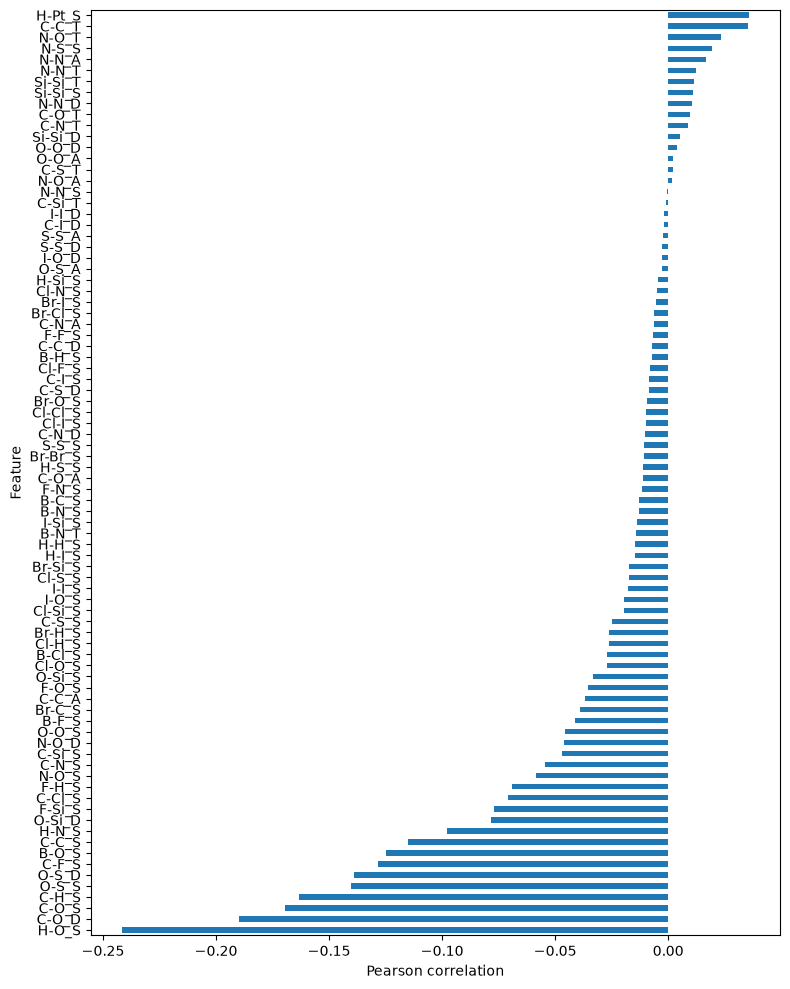

In [18]:
correlations = (
    corr["dHf_298K"]
    .drop("dHf_298K")
    .sort_values()
)

plt.figure(figsize=(8,10))

correlations.plot(kind="barh")

plt.xlabel("Pearson correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [19]:
spearman = Xy.corr(method="spearman")

spearman["dHf_298K"].sort_values()

H-O_S      -0.267311
C-O_D      -0.233234
C-O_S      -0.226803
C-H_S      -0.195500
C-C_S      -0.167436
              ...   
N-N_D       0.027510
H-Pt_S      0.028101
C-N_T       0.032808
C-C_T       0.072204
dHf_298K    1.000000
Name: dHf_298K, Length: 85, dtype: float64

In [20]:
top = (
    correlations.abs()
    .sort_values(ascending=False)
    .head(6)
    .index
)

top

Index(['H-O_S', 'C-O_D', 'C-O_S', 'C-H_S', 'O-S_S', 'O-S_D'], dtype='str')

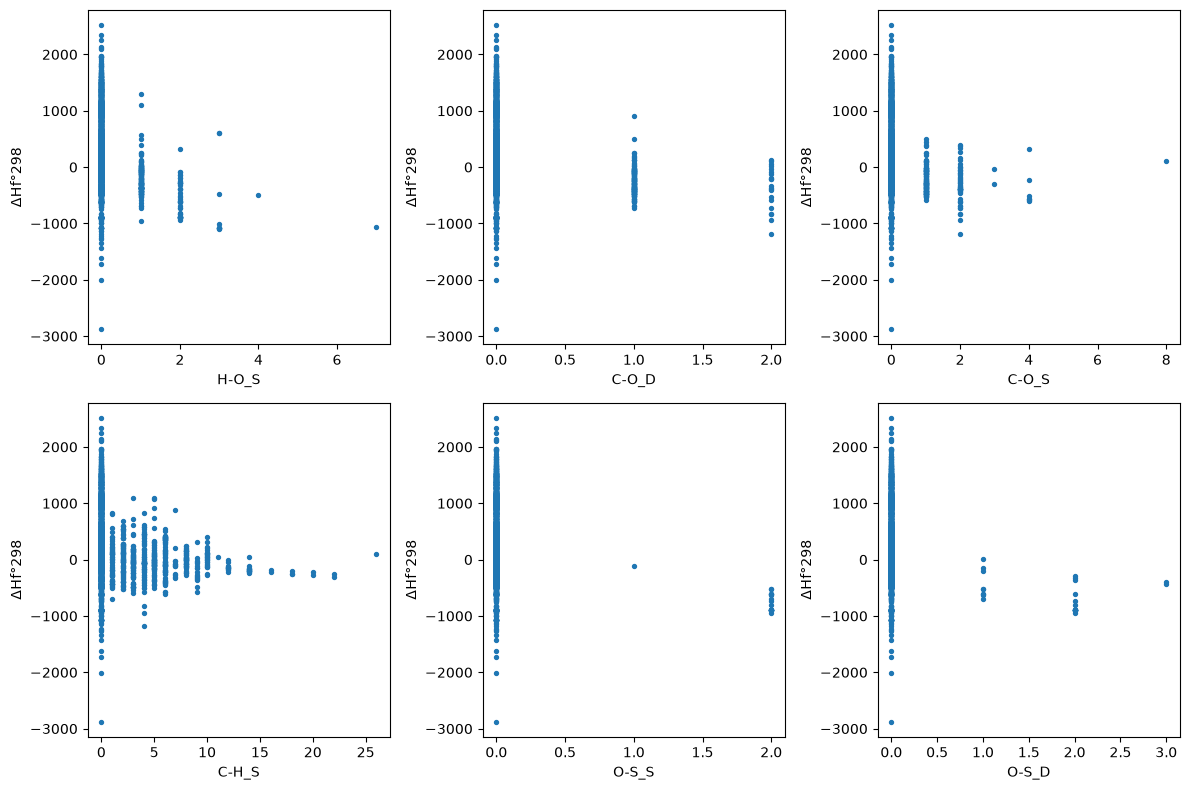

In [21]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

for ax, feature in zip(axes.ravel(), top):

    ax.scatter(df[feature], df["dHf_298K"], s=8)

    ax.set_xlabel(feature)
    ax.set_ylabel("ΔHf°298")

plt.tight_layout()
plt.show()

In [22]:
exclude = [
    "species_name",
    "formula",
    "CID",
    "Canonical_SMILES",
    "Isomeric_SMILES",
    "InChI",
    "cas_number",
    "atct_seq",
    "bond_difference"
]

numeric = df.select_dtypes(include="number")

numeric.columns
features = [
    c for c in numeric.columns
    if c not in [
        "dHf_298K",
        "dHf_0K",
        "molar_mass_uncertainty",
        "Charge"
    ]
]

In [23]:
from scipy.stats import pearsonr

results = []

for feature in features:

    valid = df[[feature, "dHf_298K"]].dropna()

    if valid[feature].nunique() <= 1:
        continue

    r, p = pearsonr(
        valid[feature],
        valid["dHf_298K"]
    )

    results.append([feature, r, p])


corr_df = (
    pd.DataFrame(
        results,
        columns=["Feature", "Pearson_r", "p_value"]
    )
    .sort_values(
        "Pearson_r",
        key=np.abs,
        ascending=False
    )
)

print(corr_df)

     Feature  Pearson_r        p_value
1   atct_seq  -0.480338  4.249383e-185
91    TRIPLE   0.300547   4.777237e-68
13     H-O_S  -0.241539   7.292406e-44
14     C-O_D  -0.189735   2.046635e-27
17     C-O_S  -0.169462   4.025653e-22
..       ...        ...            ...
80     C-I_D  -0.001996   9.099516e-01
79     I-I_D  -0.001996   9.099516e-01
81     N-O_A   0.001704   9.230956e-01
69    C-Si_T  -0.000792   9.642136e-01
58     N-N_S  -0.000344   9.844686e-01

[94 rows x 3 columns]


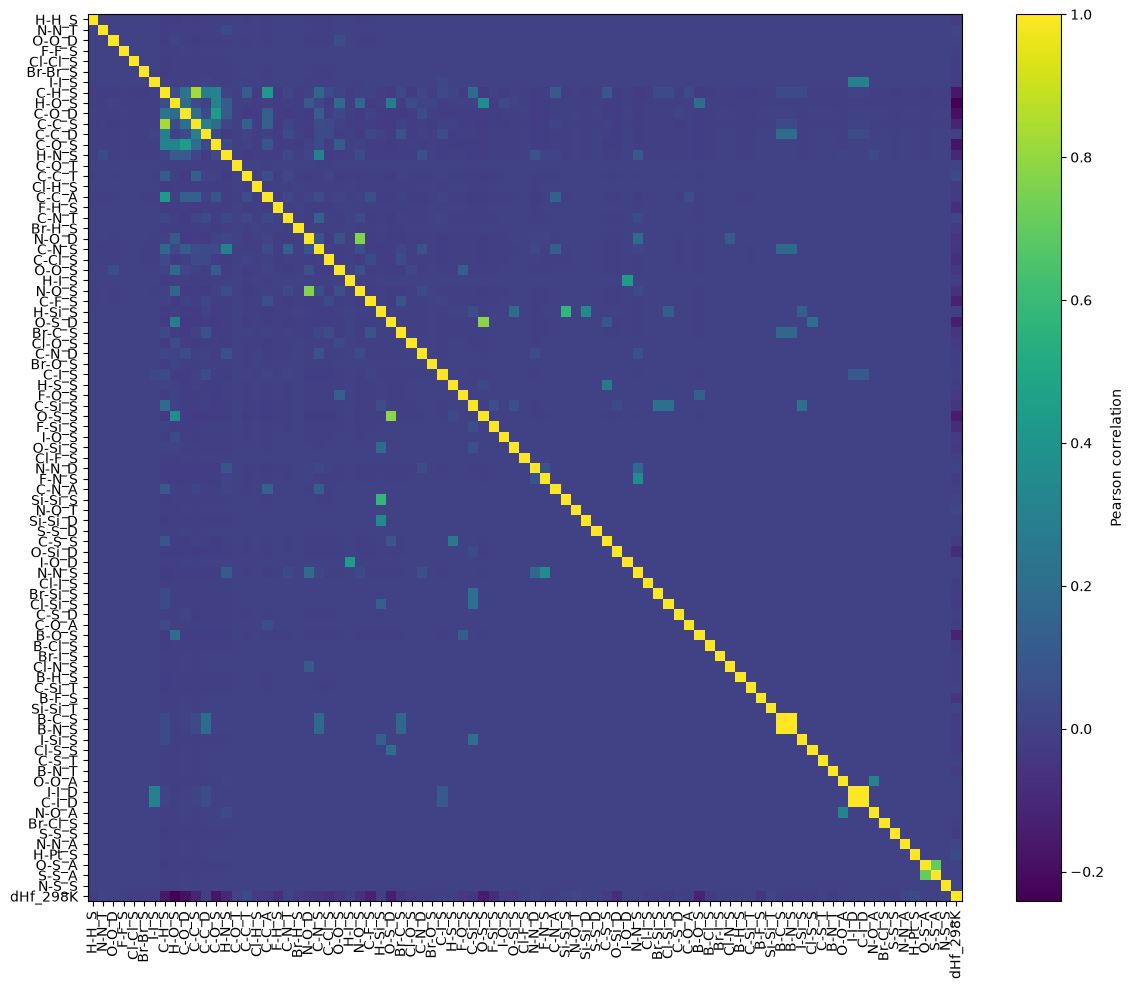

In [24]:
plt.figure(figsize=(12,10))

plt.imshow(corr, aspect="auto")

plt.colorbar(label="Pearson correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.index)),
    corr.index
)

plt.tight_layout()
plt.show()

In [25]:
top_features = corr_df["Feature"].head(10)

print(top_features)

1               atct_seq
91                TRIPLE
13                 H-O_S
14                 C-O_D
17                 C-O_S
89                SINGLE
4                    CID
12                 C-H_S
3     number_of_elements
43                 O-S_S
Name: Feature, dtype: str


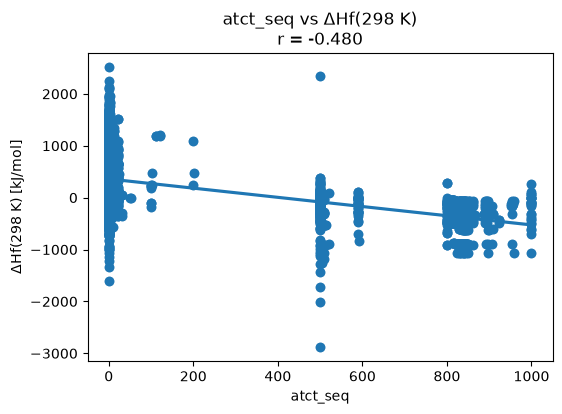

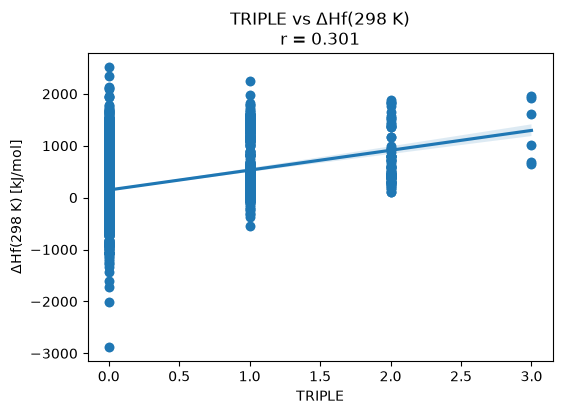

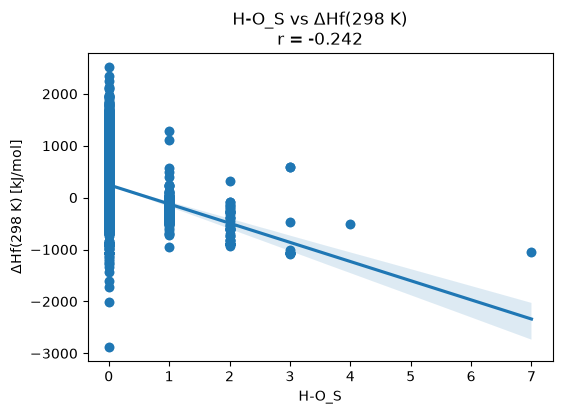

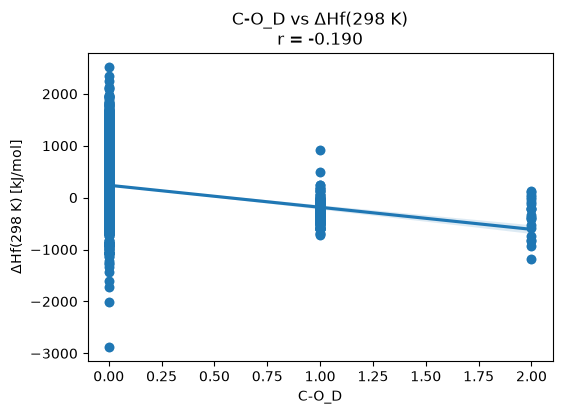

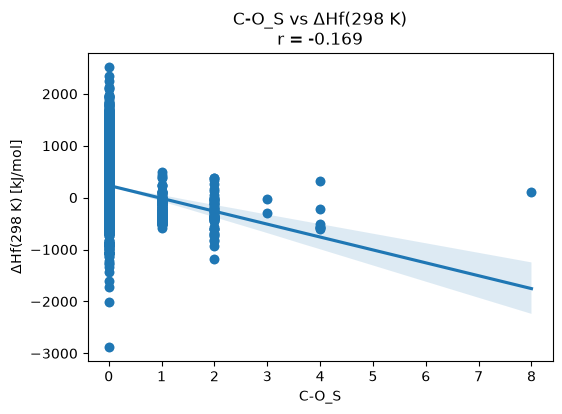

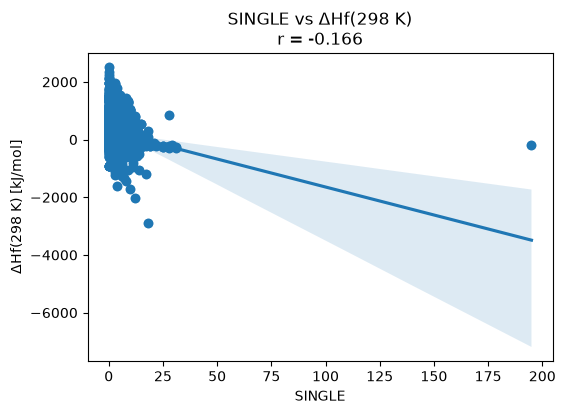

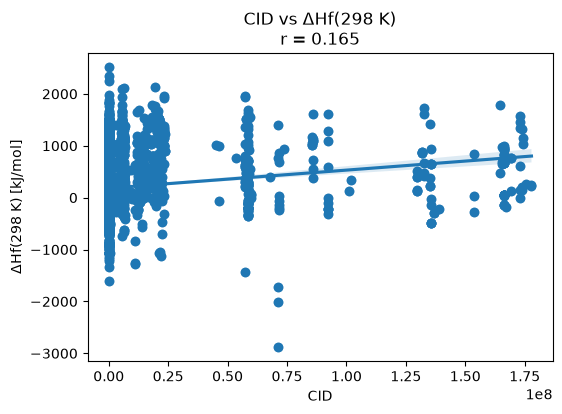

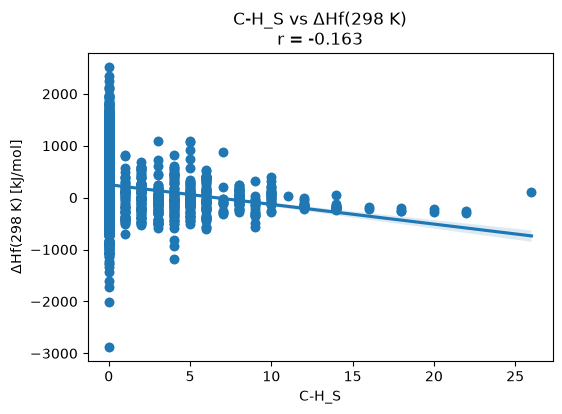

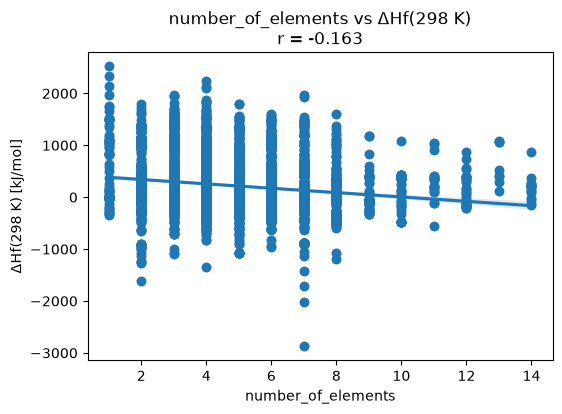

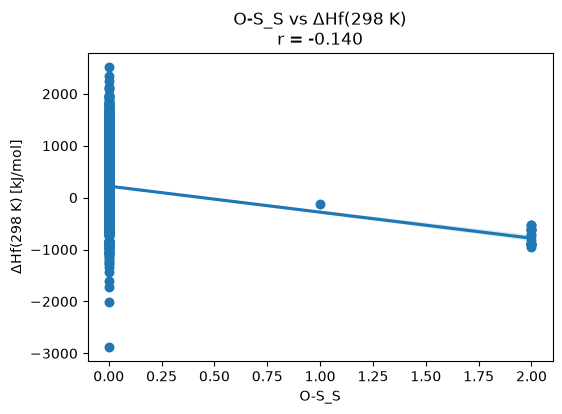

In [26]:
import seaborn as sns

for feature in top_features:

    r = corr_df.loc[
        corr_df["Feature"] == feature,
        "Pearson_r"
    ].values[0]

    plt.figure(figsize=(6,4))

    plt.scatter(
        df[feature],
        df["dHf_298K"]
    )

    sns.regplot(
    data=df,
    x=feature,
    y="dHf_298K",
    scatter_kws={"alpha":0.5}
    )

    plt.xlabel(feature)
    plt.ylabel("ΔHf(298 K) [kJ/mol]")

    plt.title(
        f"{feature} vs ΔHf(298 K)\nr = {r:.3f}"
    )

    plt.show()

## 4. Descriptor filtering

Numeric descriptors are screened for constant, highly correlated, and very
sparse columns before model fitting.


In [41]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import pandas as pd
import numpy as np

# remove metadata columns
exclude = [
    "species_name",
    "formula",
    "CID",
    "Canonical_SMILES",
    "Isomeric_SMILES",
    "InChI",
    "cas_number",
    "atct_seq",
    "atct_id",
    "units",
    "Structure_source",
    "dHf_0K",
    "uncertainty_kJmol",
    "molar_mass_uncertainty",
    "cleaned_formula",
    "species_type"
]

df_ml = df.drop(columns=exclude, errors="ignore")

# remove rows without enthalpy
df_ml = df_ml.dropna(subset=["dHf_298K"])

print(df_ml.shape)

(3212, 93)


In [42]:
X = df_ml.drop(columns=["dHf_298K"])
y = df_ml["dHf_298K"]

In [43]:
constant = X.columns[X.nunique() <= 1]

print("Constant columns:")
print(constant)

X = X.drop(columns=constant)

Constant columns:
Index([], dtype='str')


In [44]:
def correlation_analysis(X, y, scaler):

    X_scaled = scaler.fit_transform(X)

    X_scaled = pd.DataFrame(
        X_scaled,
        columns=X.columns,
        index=X.index
    )

    Xy = pd.concat(
        [X_scaled, y],
        axis=1
    )

    corr = Xy.corr(method="pearson")

    return (
        corr["dHf_298K"]
        .drop("dHf_298K")
        .sort_values(
            key=np.abs,
            ascending=False
        )
    )

In [45]:
corr_original = (
    pd.concat([X,y],axis=1)
    .corr()["dHf_298K"]
    .drop("dHf_298K")
    .sort_values(key=np.abs, ascending=False)
)

In [46]:
corr_standard = correlation_analysis(
    X,
    y,
    StandardScaler()
)

#print(corr_standard.head(20))

In [51]:
corr_minmax = correlation_analysis(
    X,
    y,
    MinMaxScaler()
)
#print(corr_minmax.head(20))

In [47]:
corr_robust = correlation_analysis(
    X,
    y,
    RobustScaler()
)

#print(corr_robust.head(20))

In [52]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()
comparison = pd.DataFrame({
    "Original": corr_original,
    "Standard": corr_standard,
    "MinMax": corr_minmax,
    "Robust": corr_robust
})

comparison.head(30)

,Original,Standard,MinMax,Robust
TRIPLE,0.300547,0.300547,0.300547,0.300547
H-O_S,-0.241539,-0.241539,-0.241539,-0.241539
C-O_D,-0.189735,-0.189735,-0.189735,-0.189735
C-O_S,-0.169462,-0.169462,-0.169462,-0.169462
SINGLE,-0.165674,-0.165674,-0.165674,-0.165674
C-H_S,-0.163346,-0.163346,-0.163346,-0.163346
number_of_elements,-0.162517,-0.162517,-0.162517,-0.162517
O-S_S,-0.140434,-0.140434,-0.140434,-0.140434
O-S_D,-0.138877,-0.138877,-0.138877,-0.138877
molar_mass,-0.136326,-0.136326,-0.136326,-0.136326


In [ ]:
import chemml.preprocessing as cp

print(dir(cp))

In [ ]:
import chemml
print(chemml.__version__)

In [ ]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

to_drop = [
    column 
    for column in upper.columns
    if any(upper[column] > 0.95)
]

print("Removing:", len(to_drop))
print(to_drop[:20])

X_reduced = X.drop(columns=to_drop)

In [ ]:
sparsity = (
    (X == 0).sum() / len(X)
).sort_values(ascending=False)

print(sparsity.head(30))

In [ ]:
min_occurrences = int(0.01 * len(X))

sparse_features = X.columns[
    (X != 0).sum() < min_occurrences
]

print("Removing sparse features:", len(sparse_features))

X = X.drop(columns=sparse_features)

print("Final feature number:", X.shape[1])

In [ ]:
print(X.columns.tolist())

In [ ]:
df_clean = pd.concat(
    [
        X,
        y,
    ],
    axis=1,
)

df_clean.to_csv(
    "../data/ATcT_ML_features_clean.csv",
    index=False,
)


In [ ]:

plt.figure(figsize=(12,10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0
)

plt.show()

In [ ]:
Xy = pd.concat(
    [X, y],
    axis=1
)

corr = (
    Xy.corr()["dHf_298K"]
    .sort_values(
        key=abs,
        ascending=False
    )
)

print(corr)

## 5. Random Forest baseline and charge ablation


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)


rf.fit(
    X_train,
    y_train
)


y_pred = rf.predict(X_test)


print(
    "MAE:",
    mean_absolute_error(y_test,y_pred)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test,y_pred))
)

print(
    "R2:",
    r2_score(y_test,y_pred)
)

In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance.head(20))

In [ ]:
X_no_charge = X.drop(columns=["Charge"])

In [ ]:
rf_no_charge = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_no_charge.fit(
    X_train.drop(columns=["Charge"]),
    y_train
)

y_pred_nc = rf_no_charge.predict(
    X_test.drop(columns=["Charge"])
)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_charge = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

rmse_no_charge = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_nc
    )
)

print("With charge:", rmse_charge)
print("Without charge:", rmse_no_charge)

In [ ]:
neutral = df[
    df["Charge"] == 0
]

print(len(neutral))

## 6. Additional exploratory models

These cells document exploratory interaction features and workshop-software
experiments that were not used as the principal reported model.


In [ ]:
X["abs_charge"] = abs(X["Charge"])

for col in [
    "H-O_S",
    "C-O_S",
    "C-C_D",
    "C-C_T",
    "TRIPLE"
]:
    X[f"{col}_charge"] = X[col] * X["Charge"]

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

model.fit(
    X_train,
    y_train.values.ravel()
)

pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

print(rmse)